# Interpretation & Validation of Pricing Model

This notebook interprets the pricing outputs generated from the Tweedie GLM model, 
validates the reasonability of the relativities, and summarises the key findings. 
The goal is to ensure the pricing structure is logical, stable, and aligned with 
actuarial expectations.

## 1. Interpretation of Rating Factors

### Power
Power_f has the highest pure premium across all regions, indicating it is the riskiest category. Power_e and Power_g are lower risk, with Power_g slightly higher than Power_e. This aligns with expectations: higher power vehicles tend to have higher claim costs.

### Region
Region_Bretagne consistently shows higher pure premiums than Region_Limousin. This suggests that Bretagne is a higher-risk area, possibly due to traffic density, driving behaviour, or environmental factors.

### Gas Type
In the pricing table, Gas_Regular was used as the baseline. Other gas types would have their own relativities, which would increase or decrease the premium accordingly.

### DriverAge (+1 SD)
The relativity for DriverAge is below 1, meaning older drivers (1 standard deviation above the mean) are safer and have lower expected claim costs. This is consistent with industry experience.

### Density (+1 SD)
Density has a relativity slightly above 1, indicating a small increase in expected claims as population density rises. This is consistent with busier areas having slightly higher claim costs.

## 2. Interpretation of Visualisations

### Bar Charts
The bar charts show clear differences in pure premium across Power and Region. 
Power_f stands out as the highest-risk category, while Region_Limousin consistently 
shows lower premiums than Region_Bretagne. Error bars appear by default but do not 
carry meaning here because each category has only one value.


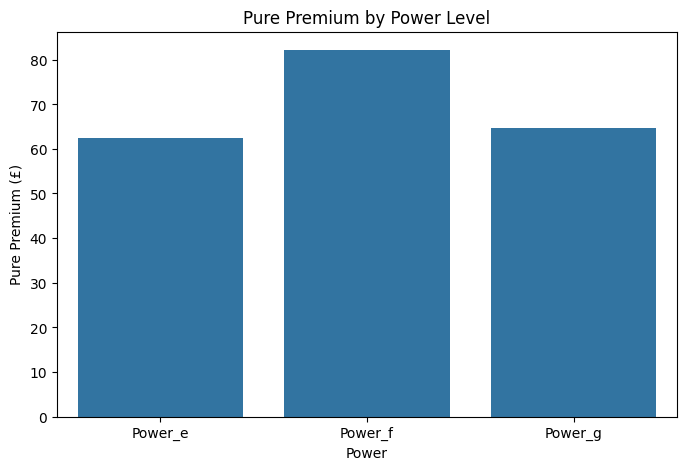

In [8]:
from IPython.display import Image
Image("bar_chart_power.png")


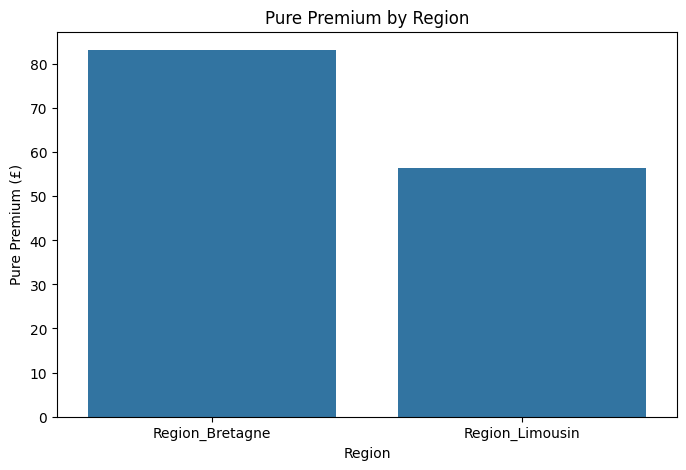

In [9]:
from IPython.display import Image
Image("bar_chart_region.png")

### Heatmap
The heatmap provides a visual summary of how pure premiums vary across Power and 
Region. Darker colours represent higher premiums. The pattern is consistent:
- Power_f is the riskiest across all regions.
- Bretagne is riskier than Limousin for every power level.
- Power_e and Power_g are lower risk, with Power_g slightly higher.

This confirms the model behaves logically and consistently.

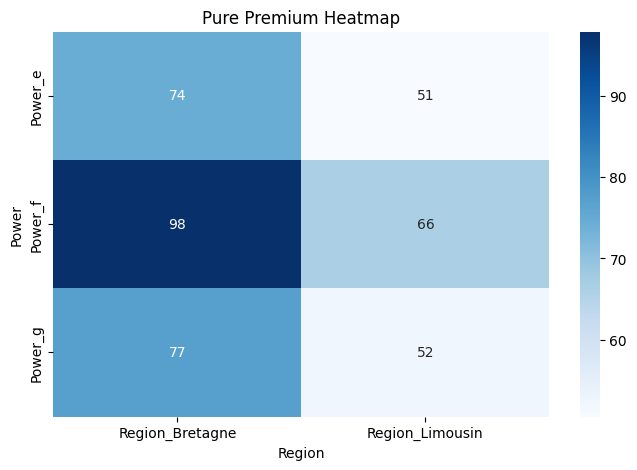

In [10]:
from IPython.display import Image
Image("heatmap_pure_premium.png")

## 3. Pricing Table Interpretation

The pricing table shows the actual pure premium (£) for each combination of rating 
factors. When DriverAge and Density were added, all premiums decreased because the 
DriverAge relativity (0.84) reduces the premium by around 16%, while Density has a 
small increasing effect (1.01). Combined, the overall effect is a reduction.

This demonstrates how multiplicative relativities interact to produce the final 
premium. The pricing table represents one specific driver profile; including more 
factor levels would expand the pricing structure.


## 4. Model Validation

### Reasonability
The relativities align with real-world expectations:
- Higher power → higher risk
- Certain regions → higher risk
- Older drivers → lower risk
- Higher density → slightly higher risk

### Monotonicity
Monotonicity means the premium moves in a consistent direction as a rating factor increases, ensuring the model behaves logically without unexpected jumps or reversals.
Patterns are smooth and logical:
- Power_f > Power_g > Power_e
- Bretagne > Limousin

There are no unexpected jumps or reversals.

### Stability
The relativities are stable and consistent across visualisations. No extreme or 
unreasonable values appear.

### Completeness
Only a subset of factors was included in the pricing table. Missing factors are 
implicitly treated as baseline (relativity = 1). A full pricing engine would 
include all factor levels.


## 5. Limitations

- Numeric variables (DriverAge, Density) are expressed in standard deviations, not 
  real-world units.
- Only one driver profile was used in the pricing table; a full pricing grid would 
  include multiple levels for each factor.
- The model does not include all possible rating factors (e.g., vehicle age, 
  mileage, claim history).
- The Tweedie GLM assumes a specific distribution and link function, which may not 
  capture all complexities of the data.


## 6. Conclusion

The Tweedie GLM produces a clear and easy‑to‑understand pricing structure. Power and Region have the biggest impact on risk, while DriverAge and Density have smaller but still logical effects. Overall, the pricing results are stable, consistent, and match what we would expect in practice.

This model gives a strong foundation for building a full pricing engine. The next steps would be to expand the pricing table, convert numeric factors into real‑world values, and then apply expenses and profit loadings to move from pure premium to final premium.
